In [1]:
# =============================================================================
# EXPERIMENTAL SPECTRA: average per experiment + parameters
# =============================================================================
# Each spectra/{1..22}/ folder holds one CSV per shot (energy,intensity), all on
# the same 450-point energy axis. params.csv gives the settings per experiment.
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SPECTRA_DIR = "spectra"
PARAMS_CSV  = "params.csv"

params = pd.read_csv(PARAMS_CSV).set_index("experiment")

def load_experiment(exp):
    """Return (energy, mean_intensity, std_intensity, n_shots) for one experiment."""
    files = sorted(glob.glob(os.path.join(SPECTRA_DIR, str(exp), "*.csv")))
    energy = None
    stack = []
    for fn in files:
        df = pd.read_csv(fn)
        if energy is None:
            energy = df["energy"].values
        stack.append(df["intensity"].values)
    stack = np.array(stack)
    return energy, stack.mean(axis=0), stack.std(axis=0), len(files)

def param_label(exp):
    """One-line summary of an experiment's settings from params.csv."""
    r = params.loc[exp]
    return f"E={r.E}, P={r.P} bar, t={r.ms} ms, gain={r.gain}, N={r.perc_N}%"

available = sorted(int(d) for d in os.listdir(SPECTRA_DIR)
                   if d.isdigit() and os.path.isdir(os.path.join(SPECTRA_DIR, d)))
print(f"Experiments found: {available}")


Experiments found: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]


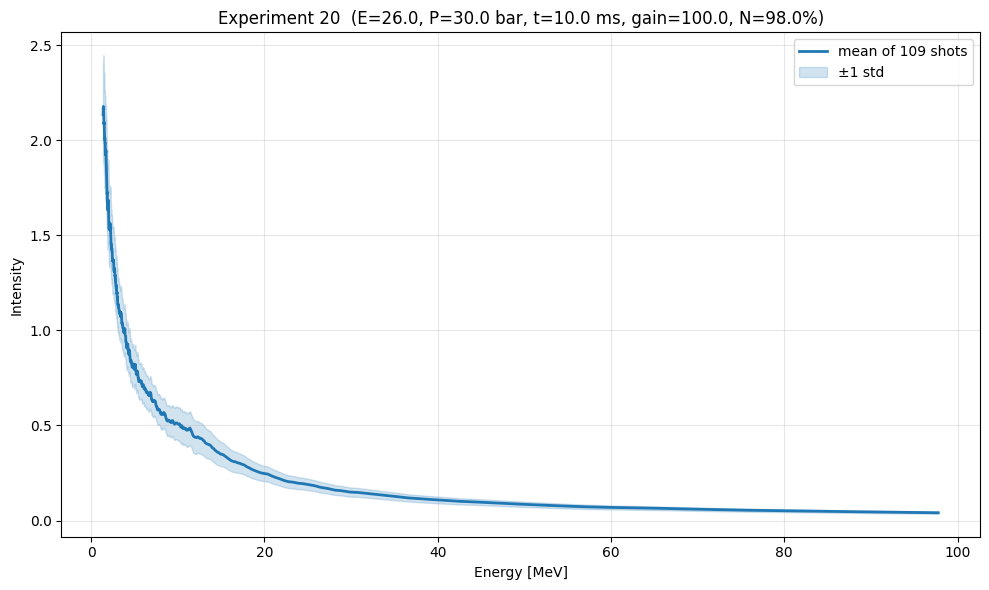

In [2]:
# ---- single experiment: mean spectrum + std band, params in the title --------
EXPERIMENT = 20   # <-- choose 1..22

energy, mean, std, n = load_experiment(EXPERIMENT)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(energy, mean, color="#1f77b4", lw=2, label=f"mean of {n} shots")
ax.fill_between(energy, mean - std, mean + std, color="#1f77b4", alpha=0.2, label="±1 std")
ax.set_xlabel("Energy [MeV]")
ax.set_ylabel("Intensity")
ax.set_title(f"Experiment {EXPERIMENT}  ({param_label(EXPERIMENT)})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SPECTRA_DIR, f"experiment_{EXPERIMENT}_mean.png"), dpi=200, bbox_inches="tight")
plt.show()


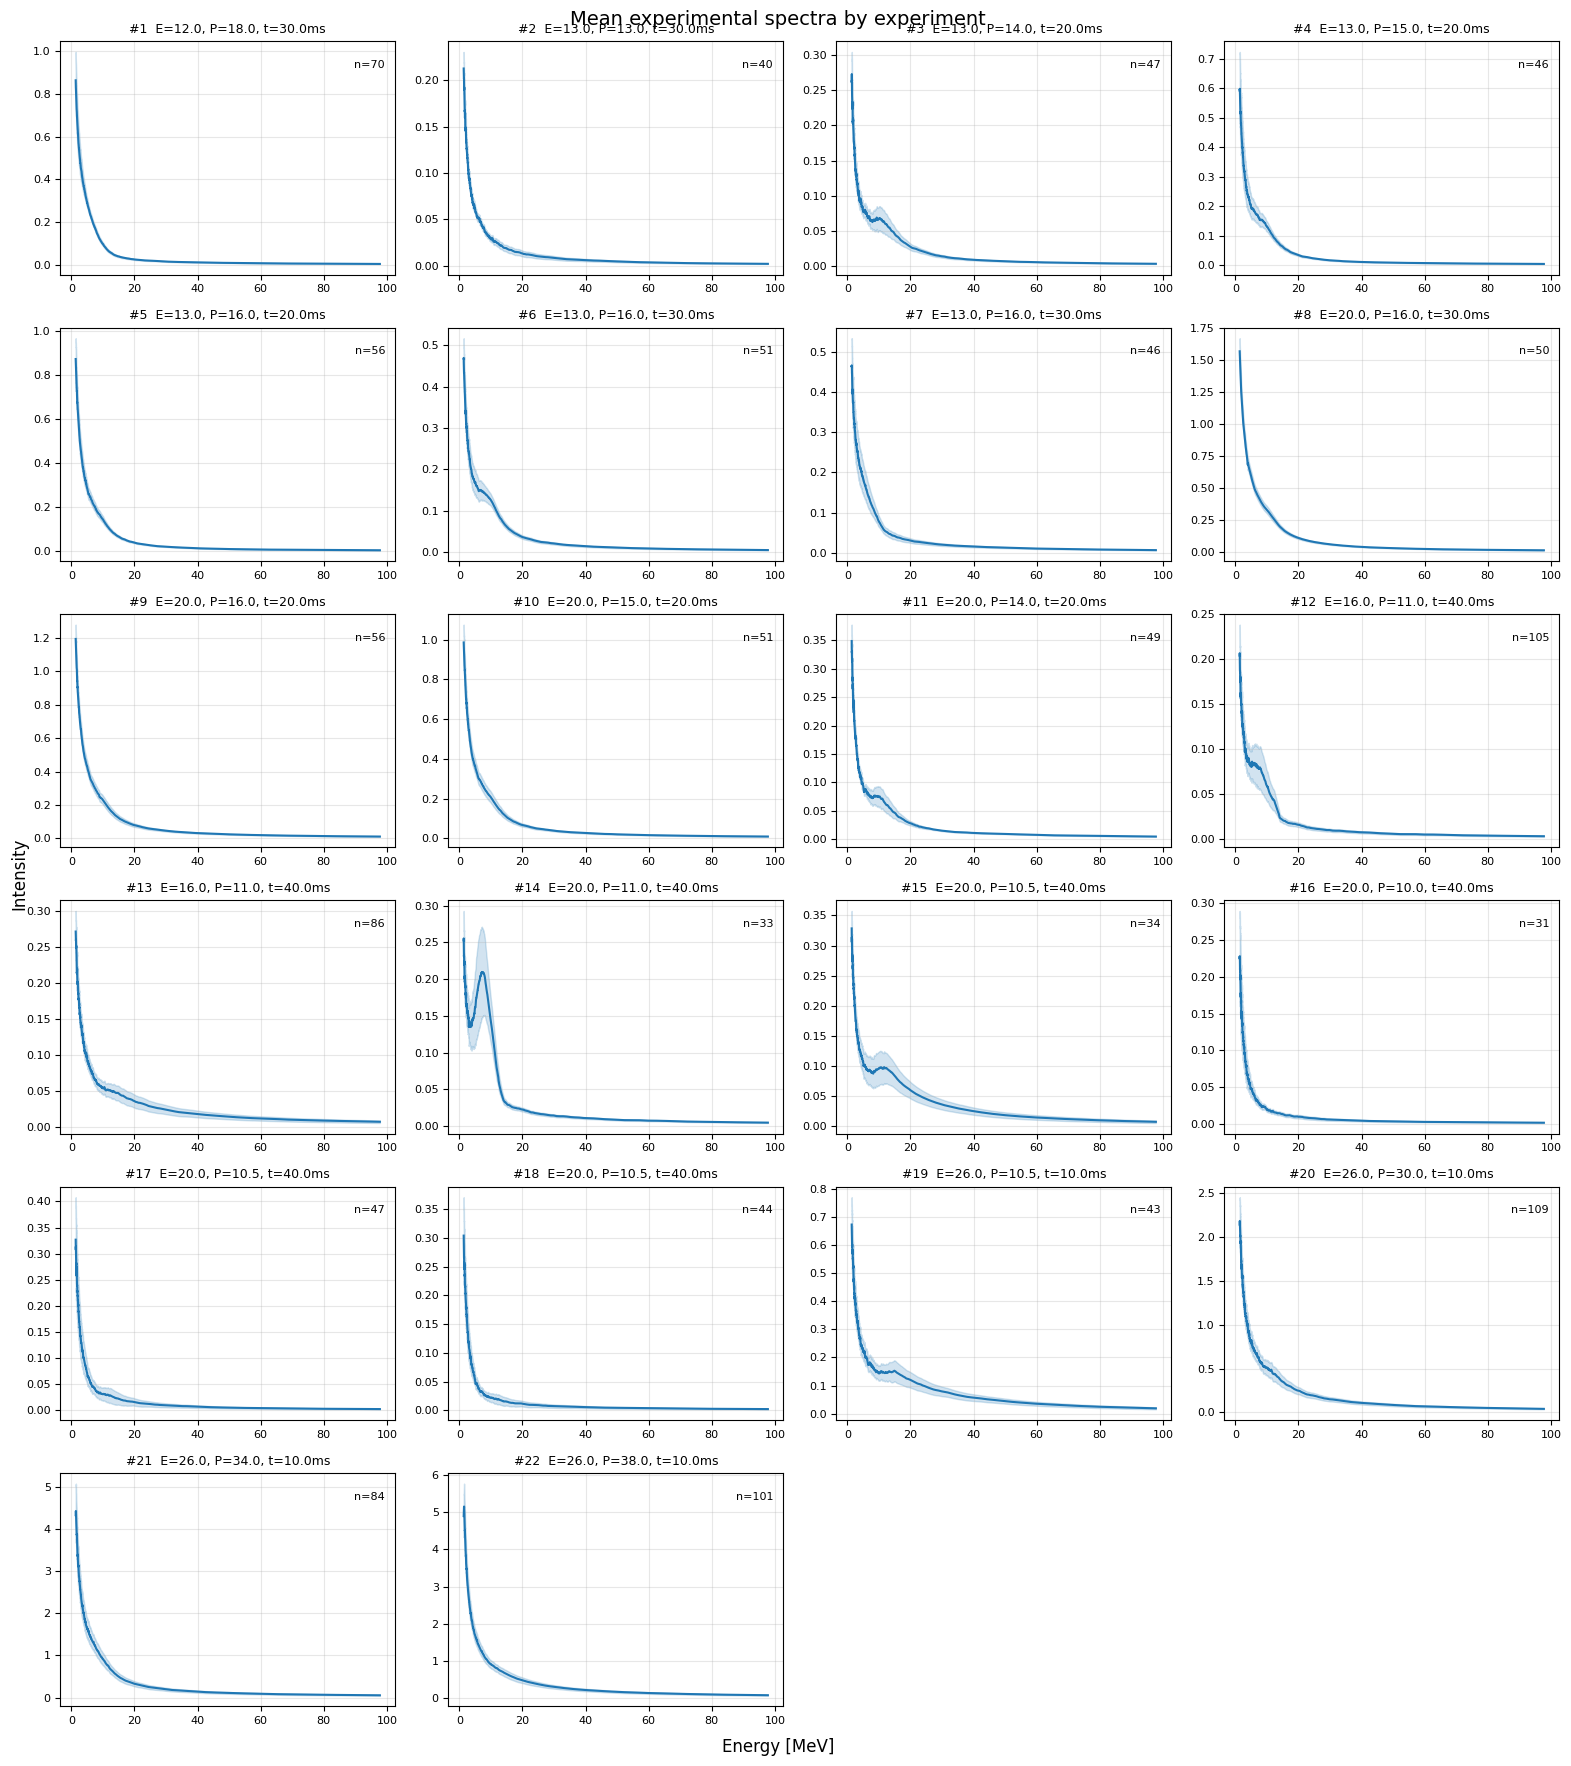

In [3]:
# ---- all experiments: grid of mean spectra, each annotated with its params ----
ncols = 4
nrows = int(np.ceil(len(available) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)

for ax, exp in zip(axes.flat, available):
    energy, mean, std, n = load_experiment(exp)
    ax.plot(energy, mean, color="#1f77b4", lw=1.5)
    ax.fill_between(energy, mean - std, mean + std, color="#1f77b4", alpha=0.2)
    r = params.loc[exp]
    ax.set_title(f"#{exp}  E={r.E}, P={r.P}, t={r.ms}ms", fontsize=9)
    ax.text(0.97, 0.92, f"n={n}", transform=ax.transAxes, ha="right", va="top", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=8)

# hide any unused axes
for ax in axes.flat[len(available):]:
    ax.axis("off")

fig.supxlabel("Energy [MeV]")
fig.supylabel("Intensity")
fig.suptitle("Mean experimental spectra by experiment", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(SPECTRA_DIR, "all_experiments_mean_grid.png"), dpi=200, bbox_inches="tight")
plt.show()
